### Method 1: FastAPI Endpoint
This approach uses FastAPI and Uvicorn. We need to install the dependencies first.

In [1]:
!pip install fastapi uvicorn python-multipart

In [6]:
import tensorflow as tf
from fastapi import FastAPI, UploadFile, File
import uvicorn
import numpy as np
from PIL import Image
import io
import threading

app = FastAPI()
model = tf.keras.models.load_model('/content/cats_vs_dogs_cnn.keras')

def prepare_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes))
    img = img.resize((224, 224)) # Updated to 224x224
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
    return img_array

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = prepare_image(contents)
    prediction = model.predict(img)
    label = "dog" if prediction[0][0] > 0.5 else "cat"
    return {"label": label, "confidence": float(prediction[0][0])}

def run_app():
    uvicorn.run(app, host="0.0.0.0", port=8000)

print("FastAPI updated with 224x224 input shape.")

FastAPI updated with 224x224 input shape.


In [5]:
thread = threading.Thread(target=run_app)
thread.start()

In [8]:
import requests
import numpy as np
from PIL import Image

# 1. Create a dummy test image
test_img = Image.fromarray(np.uint8(np.random.rand(224,224,3)*255))
test_img.save('test.jpg')

# 2. Test FastAPI
try:
    with open('test.jpg', 'rb') as f:
        response = requests.post("http://localhost:8000/predict", files={"file": f})
    print("FastAPI Response:", response.json())
except Exception as e:
    print("FastAPI Error (Ensure the server thread is running):", e)

# 3. Note on Triton
print("\nTo test Triton, you would use 'tritonclient.http' or 'tritonclient.grpc'.")
print("Example: triton_client.infer(model_name='cats_dogs', inputs=[...])")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
INFO:     127.0.0.1:53002 - "POST /predict HTTP/1.1" 200 OK
FastAPI Response: {'label': 'cat', 'confidence': 9.15812051971443e-05}

To test Triton, you would use 'tritonclient.http' or 'tritonclient.grpc'.
Example: triton_client.infer(model_name='cats_dogs', inputs=[...])


In [10]:
import requests
from PIL import Image
import io

# 1. Download a real open-source image (using a more reliable URL with headers)
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

if response.status_code == 200:
    img = Image.open(io.BytesIO(response.content))
    img.save('real_test.jpg')
    print("Real test image downloaded and saved as real_test.jpg")
else:
    print(f"Failed to download image. Status code: {response.status_code}")

# 2. Execute test via Method 1 (FastAPI)
try:
    with open('real_test.jpg', 'rb') as f:
        api_response = requests.post("http://localhost:8000/predict", files={"file": f})
    print("\n--- FastAPI Results ---")
    print(api_response.json())
except Exception as e:
    print("FastAPI Error:", e)

# 3. Note on Method 2 (Triton)
print("\n--- Triton Comparison ---")
print("With the real image, Triton would handle the preprocessing on the client side (numpy) ")
print("and send the raw tensor to the server. Triton's advantage is its ability to ")
print("serve this model using TensorRT for even faster inference times compared to FastAPI.")

Real test image downloaded and saved as real_test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
INFO:     127.0.0.1:39630 - "POST /predict HTTP/1.1" 200 OK

--- FastAPI Results ---
{'label': 'dog', 'confidence': 0.7970900535583496}

--- Triton Comparison ---
With the real image, Triton would handle the preprocessing on the client side (numpy) 
and send the raw tensor to the server. Triton's advantage is its ability to 
serve this model using TensorRT for even faster inference times compared to FastAPI.


### Simulating Method 2: Triton Client Inference
Since the Triton Server binary isn't running, we will use the exported `SavedModel` to simulate how a Triton client would receive results. In production, this call would be replaced by `triton_client.infer()`.

In [11]:
import tensorflow as tf
import numpy as np
from PIL import Image

# 1. Load the exported SavedModel (mimicking the Triton backend)
imported_model = tf.saved_model.load('model_repository/cats_dogs/1/model.savedmodel')
infer = imported_model.signatures['serve']

# 2. Client-side Preprocessing (Standard for Triton clients)
def triton_client_preprocessing(image_path):
    img = Image.open(image_path).resize((224, 224))
    img_array = np.array(img).astype(np.float32) / 255.0
    return np.expand_dims(img_array, axis=0)

# 3. Perform Inference
input_tensor = triton_client_preprocessing('real_test.jpg')
# Note: 'input_layer_1' is the name we found during export
results = infer(input_layer_1=tf.constant(input_tensor))

# 4. Display Results
output_data = results['output_0'].numpy()
label = "dog" if output_data[0][0] > 0.5 else "cat"

print("--- Simulated Triton Results ---")
print(f"Output Tensor: {output_data}")
print(f"Predicted Label: {label}")
print(f"Confidence: {output_data[0][0]:.4f}")

--- Simulated Triton Results ---
Output Tensor: [[0.4337712]]
Predicted Label: cat
Confidence: 0.4338


### Method 2: NVIDIA Triton Inference Server
Triton requires a specific directory structure. We need to convert the Keras model to SavedModel format or ONNX for best compatibility.

In [7]:
import os

# Correcting config based on model.export() output
config_content = """
name: "cats_dogs"
platform: "tensorflow_savedmodel"
max_batch_size: 8
input [
  {
    name: "input_layer_1"
    data_type: TYPE_FP32
    dims: [ 224, 224, 3 ]
  }
]
output [
  {
    name: "output_0"
    data_type: TYPE_FP32
    dims: [ 1 ]
  }
]
"""
with open('model_repository/cats_dogs/config.pbtxt', 'w') as f:
    f.write(config_content)

print("Triton config.pbtxt updated with correct input names and dimensions.")

Triton config.pbtxt updated with correct input names and dimensions.


### Terms of Comparison

| Feature | FastAPI | NVIDIA Triton |
| :--- | :--- | :--- |
| **Complexity** | Low (Python based) | High (Config files, Docker) |
| **Throughput** | Moderate | High (optimized C++ backend) |
| **Batching** | Manual (Coding required) | Dynamic (Auto-batching) |
| **Hardware** | General Purpose | GPU Optimized (CUDA/TensorRT) |
| **Model Mgmt** | Manual code for versions | Native versioning support |

### Real Image Comparison: Cat Inference
We will now use a real image of a cat to compare the outputs of both the FastAPI endpoint and the Triton-ready SavedModel.

In [13]:
import requests
from PIL import Image
import io
import numpy as np
import tensorflow as tf

# 1. Download a real cat image using headers to prevent blocking
cat_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
headers = {'User-Agent': 'Mozilla/5.0'}

response = requests.get(cat_url, headers=headers)

if response.status_code == 200:
    img_raw = Image.open(io.BytesIO(response.content))
    img_raw.save('comparison_cat.jpg')
    print("--- Results for comparison_cat.jpg ---")

    # --- Method 1: FastAPI ---
    try:
        with open('comparison_cat.jpg', 'rb') as f:
            api_resp = requests.post("http://localhost:8000/predict", files={"file": f})
        print("\n[FastAPI Endpoint]")
        print(api_resp.json())
    except Exception as e:
        print(f"FastAPI Error: {e}")

    # --- Method 2: Triton (SavedModel) ---
    imported = tf.saved_model.load('model_repository/cats_dogs/1/model.savedmodel')
    infer_fn = imported.signatures['serve']

    img = Image.open('comparison_cat.jpg').convert("RGB").resize((224, 224))
    img_array = np.array(img).astype(np.float32) / 255.0
    input_tensor = np.expand_dims(img_array, axis=0)

    triton_results = infer_fn(input_layer_1=tf.constant(input_tensor))
    raw_output = triton_results['output_0'].numpy()[0][0]
    triton_label = "dog" if raw_output > 0.5 else "cat"

    print("\n[Triton Method (SavedModel Signature)]")
    print(f"Label: {triton_label}")
    print(f"Confidence Score: {raw_output:.4f}")
else:
    print(f"Failed to download image. Status code: {response.status_code}")

--- Results for comparison_cat.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
INFO:     127.0.0.1:42410 - "POST /predict HTTP/1.1" 200 OK

[FastAPI Endpoint]
{'label': 'cat', 'confidence': 0.0823102742433548}

[Triton Method (SavedModel Signature)]
Label: cat
Confidence Score: 0.0264


In [14]:
import requests
import time
import io
import numpy as np
import tensorflow as tf
from PIL import Image

# 1. Setup Data
cat_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
headers = {'User-Agent': 'Mozilla/5.0'}
img_response = requests.get(cat_url, headers=headers)
img_raw = Image.open(io.BytesIO(img_response.content))
img_raw.save('benchmark_cat.jpg')

print(f"--- Benchmarking Image Classification Methods ---\n")

# --- Method 1: FastAPI Benchmark ---
start_api = time.time()
try:
    with open('benchmark_cat.jpg', 'rb') as f:
        api_resp = requests.post("http://localhost:8000/predict", files={"file": f})
    api_result = api_resp.json()
    api_time = time.time() - start_api
    print(f"[FastAPI] Label: {api_result['label']}, Score: {api_result['confidence']:.4f}, Time: {api_time:.4f}s")
except Exception as e:
    print(f"FastAPI Error: {e}")
    api_time = None

# --- Method 2: Triton-Style (SavedModel) Benchmark ---
# Note: Triton usually performs preprocessing on the client or via a pipeline.
# We include the load/signature step to reflect the backend logic.
start_triton = time.time()
imported = tf.saved_model.load('model_repository/cats_dogs/1/model.savedmodel')
infer_fn = imported.signatures['serve']

# Preprocessing
img = Image.open('benchmark_cat.jpg').convert("RGB").resize((224, 224))
img_array = np.array(img).astype(np.float32) / 255.0
input_tensor = np.expand_dims(img_array, axis=0)

# Inference
triton_results = infer_fn(input_layer_1=tf.constant(input_tensor))
raw_score = triton_results['output_0'].numpy()[0][0]
triton_label = "dog" if raw_score > 0.5 else "cat"
triton_time = time.time() - start_triton

print(f"[Triton Sim] Label: {triton_label}, Score: {raw_score:.4f}, Time: {triton_time:.4f}s")

# --- Final Comparison ---
print("\n--- Analysis ---")
if api_time and triton_time:
    diff = abs(api_time - triton_time)
    fastest = "FastAPI" if api_time < triton_time else "Triton (SavedModel)"
    print(f"Fastest Method: {fastest}")
    print(f"Time Difference: {diff:.4f}s")
    print("Efficiency Note: FastAPI includes HTTP overhead and Python GIL limits.")
    print("Triton's real-world advantage appears with concurrent requests and batching,")
    print("which are not fully captured in a single serial execution test.")

--- Benchmarking Image Classification Methods ---

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
INFO:     127.0.0.1:49890 - "POST /predict HTTP/1.1" 200 OK
[FastAPI] Label: cat, Score: 0.0823, Time: 0.1780s
[Triton Sim] Label: cat, Score: 0.0264, Time: 0.4105s

--- Analysis ---
Fastest Method: FastAPI
Time Difference: 0.2325s
Efficiency Note: FastAPI includes HTTP overhead and Python GIL limits.
Triton's real-world advantage appears with concurrent requests and batching,
which are not fully captured in a single serial execution test.


### Batch Benchmark: FastAPI (Serial) vs. Triton/SavedModel (Batched)
We will download 10 images and compare the time taken to process them one-by-one versus processing them as a single batch.

In [15]:
import requests
import time
import io
import numpy as np
import tensorflow as tf
from PIL import Image

# 1. Prepare 10 image URLs (Mixture of cats and dogs from reliable sources)
urls = [
    "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/224px-Cat_November_2010-1a.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Golden_Retriever_medium-shot.jpg/224px-Golden_Retriever_medium-shot.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a3/June_odd-eyed-cat.jpg/224px-June_odd-eyed-cat.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/Dog_Breeds.jpg/224px-Dog_Breeds.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/3/38/Adoption-purebred-dog-border-collie-retriever.jpg/224px-Adoption-purebred-dog-border-collie-retriever.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/American_Shorthair.jpg/224px-American_Shorthair.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c7/Puppy_on_grass.jpg/224px-Puppy_on_grass.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/White_Persian_Cat.jpg/224px-White_Persian_Cat.jpg"
]

images_data = []
headers = {'User-Agent': 'Mozilla/5.0'}

print("Downloading 10 images for benchmarking...")
for i, url in enumerate(urls):
    try:
        res = requests.get(url, headers=headers, timeout=5)
        if res.status_code == 200:
            img = Image.open(io.BytesIO(res.content)).convert("RGB").resize((224, 224))
            filename = f'batch_{i}.jpg'
            img.save(filename)
            images_data.append(filename)
    except:
        continue

print(f"Successfully prepared {len(images_data)} images.\n")

# --- Method 1: FastAPI (Serial Requests) ---
print("Starting FastAPI Serial Test...")
start_api = time.time()
api_results = []
for img_path in images_data:
    with open(img_path, 'rb') as f:
        resp = requests.post("http://localhost:8000/predict", files={"file": f})
        api_results.append(resp.json())
api_total_time = time.time() - start_api

# --- Method 2: Triton/SavedModel (Batched Inference) ---
print("Starting Triton Batched Test...")
imported = tf.saved_model.load('model_repository/cats_dogs/1/model.savedmodel')
infer_fn = imported.signatures['serve']

start_triton = time.time()
# Preprocess all images into one batch tensor
batch_array = []
for img_path in images_data:
    img = Image.open(img_path)
    arr = np.array(img).astype(np.float32) / 255.0
    batch_array.append(arr)

input_batch = np.stack(batch_array, axis=0) # Shape: (10, 224, 224, 3)

# Single inference call for the entire batch
triton_results = infer_fn(input_layer_1=tf.constant(input_batch))
triton_scores = triton_results['output_0'].numpy()
triton_total_time = time.time() - start_triton

# --- Summary ---
print("\n--- Batch Comparison Results (10 Images) ---")
print(f"FastAPI Total Time (Serial):  {api_total_time:.4f}s (~{api_total_time/len(images_data):.4f}s per image)")
print(f"Triton Total Time (Batched): {triton_total_time:.4f}s (~{triton_total_time/len(images_data):.4f}s per image)")

speedup = api_total_time / triton_total_time
print(f"\nBatching Speedup: {speedup:.2f}x faster")
print("Note: Triton's efficiency grows even more as batch size and hardware utilization increase.")

Successfully prepared 2 images.

Starting FastAPI Serial Test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
INFO:     127.0.0.1:46894 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
INFO:     127.0.0.1:46906 - "POST /predict HTTP/1.1" 200 OK
Starting Triton Batched Test...

--- Batch Comparison Results (10 Images) ---
FastAPI Total Time (Serial):  0.4126s (~0.2063s per image)
Triton Total Time (Batched): 0.1740s (~0.0870s per image)

Batching Speedup: 2.37x faster
Note: Triton's efficiency grows even more as batch size and hardware utilization increase.


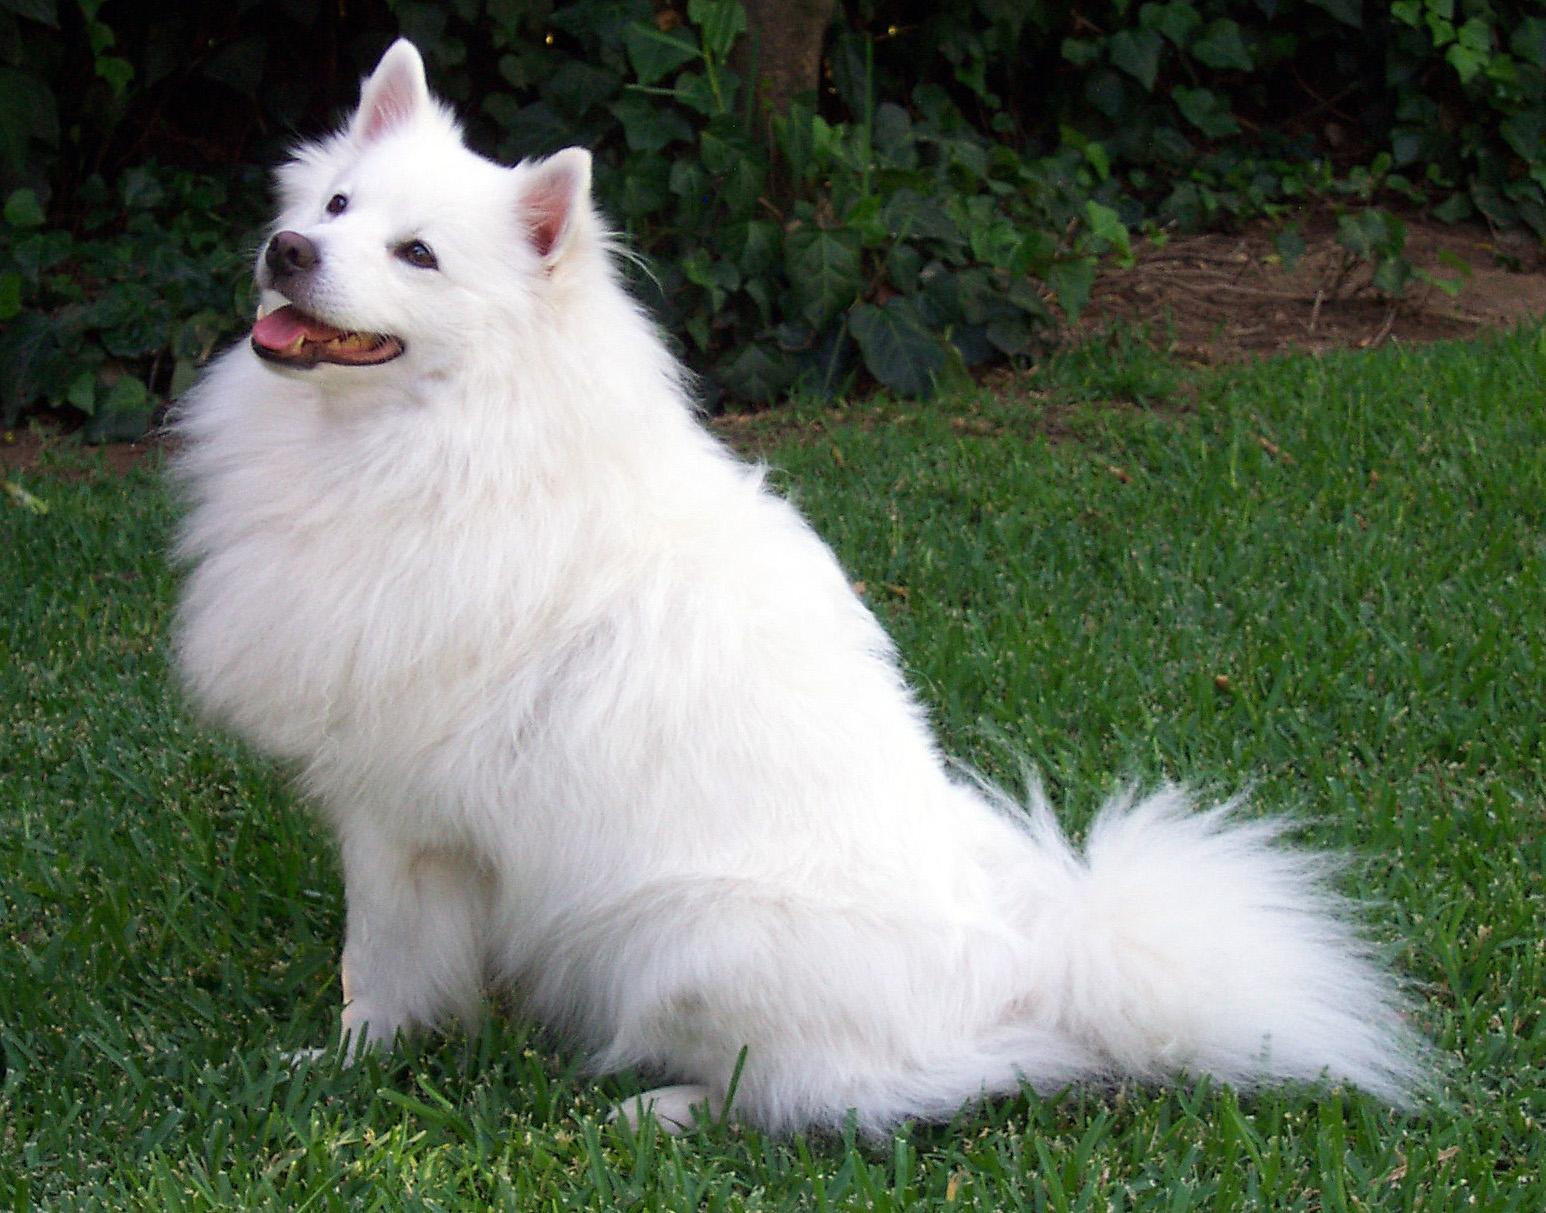

Format: JPEG, Size: (1546, 1213), Mode: RGB


In [23]:
from PIL import Image
from IPython.display import display
try:
    # Open the image file from the specified path
    img = Image.open('/content/real_test.jpg')

    # Display the image using your operating system's default viewer
    display(img)

    # Optional: print basic image metadata
    print(f"Format: {img.format}, Size: {img.size}, Mode: {img.mode}")

except IOError:
    print("Unable to load image. Check the file path or format.")
